## Notebook 04 - DL Model: BERT Fine-tuning 
## NLP Assignment -Fake News Detection 
## Person 3: N.A.Matheesha Desaman (CIT-24-01-0435)

# Deep Learning Model: BERT Fine-tuning
**Why BERT?** BERT (Bidirectional Encoder Representations from Transformers)
reads text in both directions simultaneously. Unlike LSTM which reads left-to-right,
BERT understands full context. Fine-tuning means we take a pre-trained BERT
and teach it specifically to detect fake news.

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Libraries imported!")
print(f" Using device: {device}")

 Libraries imported!
 Using device: cpu


In [2]:
df = pd.read_csv('../data/welFake_cleaned.csv')

sample_df = df.sample(n=3000, random_state=42).reset_index(drop=True)

texts  = sample_df['final_text'].astype(str).tolist()
labels = sample_df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 2400
Test samples: 600


In [3]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts    = texts
        self.labels   = labels
        self.tokenizer = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = FakeNewsDataset(X_train, y_train, tokenizer)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

print(" Datasets and DataLoaders created!")

 Datasets and DataLoaders created!


In [4]:
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)

print(" BERT model loaded!")
print(f"Total parameters: {sum(p.numel() for p in bert_model.parameters()):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 BERT model loaded!
Total parameters: 109,483,778


In [5]:
EPOCHS = 2  # Keep at 2 for CPU; increase to 3-4 if you have GPU

optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)

print(f"Training for {EPOCHS} epochs")
print(f"Total training steps: {total_steps}")

Training for 2 epochs
Total training steps: 300


In [6]:
train_losses = []

for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0
    
    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids,
                             attention_mask=attention_mask,
                             labels=labels_batch)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if (batch_idx + 1) % 20 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"\n Epoch {epoch+1} complete! Average Loss: {avg_loss:.4f}\n")

print(" Training complete!")

  Epoch 1 | Batch 20/150 | Loss: 0.7009
  Epoch 1 | Batch 40/150 | Loss: 0.3869
  Epoch 1 | Batch 60/150 | Loss: 0.3037
  Epoch 1 | Batch 80/150 | Loss: 0.3572
  Epoch 1 | Batch 100/150 | Loss: 0.1804
  Epoch 1 | Batch 120/150 | Loss: 0.2241
  Epoch 1 | Batch 140/150 | Loss: 0.2047

 Epoch 1 complete! Average Loss: 0.3758

  Epoch 2 | Batch 20/150 | Loss: 0.0640
  Epoch 2 | Batch 40/150 | Loss: 0.2421
  Epoch 2 | Batch 60/150 | Loss: 0.0227
  Epoch 2 | Batch 80/150 | Loss: 0.0311
  Epoch 2 | Batch 100/150 | Loss: 0.0112
  Epoch 2 | Batch 120/150 | Loss: 0.1107
  Epoch 2 | Batch 140/150 | Loss: 0.0663

 Epoch 2 complete! Average Loss: 0.1264

 Training complete!


In [7]:
bert_model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['label'].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1       = f1_score(all_labels, all_preds)

print("=" * 40)
print("BERT FINE-TUNING RESULTS")
print("=" * 40)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

BERT FINE-TUNING RESULTS
Accuracy: 0.9517
F1-Score: 0.9539

Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95       286
        Real       0.95      0.96      0.95       314

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



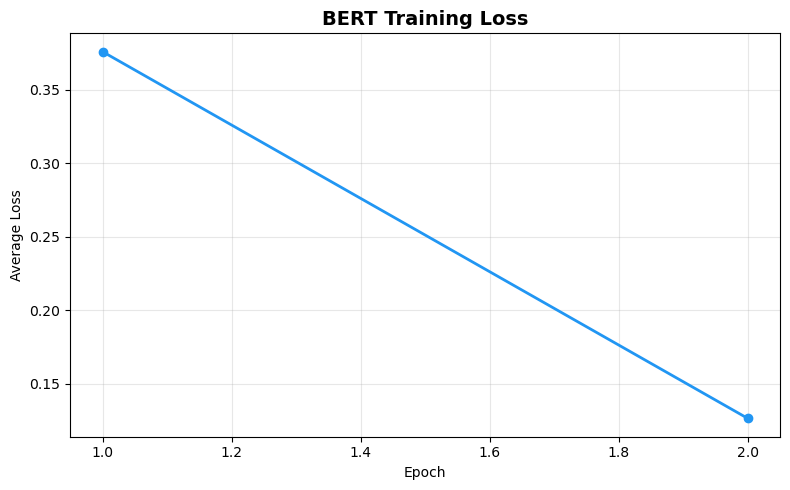

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', color='#2196F3', linewidth=2)
plt.title('BERT Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../screenshots/07_bert_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
bert_model.save_pretrained('../models/bert_fake_news')
tokenizer.save_pretrained('../models/bert_fake_news')
print("Model saved to models/bert_fake_news/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to models/bert_fake_news/
